In [ ]:
import importlib

import ibis
import polars as pl
import pygraphviz as pgv
from ibis import deferred as _
from polars.testing import assert_frame_equal

import datasets
import datasets.fake
import pvm
import pvm.formulas
import pvm.measures
import pvm.measures.dot_graph
import pvm.pvm
from pvm.pvm import PVM

importlib.reload(pvm.formulas)
importlib.reload(pvm.pvm)
importlib.reload(datasets)
importlib.reload(pvm)
importlib.reload(pvm.measures)
importlib.reload(datasets.fake)
importlib.reload(pvm.measures.dot_graph)
pass
pvm.__version__

from pvm.measures import CompositeRateMeasure, Measure, QuantityMeasure, RateMeasure

In [5]:
price = RateMeasure(
    "unit_price",
    definition=(_.volume * _.unit_price).sum() / _.volume.sum(),
    components=[
        QuantityMeasure(
            "price_in_lc",
            definition=(_.volume * _.price_in_lc).sum() / _.volume.sum(),
        ),
        RateMeasure(
            "fx_rate",
            definition=(_.volume * _.fx_rate * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum(),
        ),
    ],
)

revenue_graph = Measure(
    "revenue",
    definition=_.revenue.sum(),
    reconcile=True,
    components=[
        price,
        QuantityMeasure(
            "volume",
            definition=_.volume.sum(),
        ),
        Measure("flat_fee", definition=_.flat_fee.sum()),
    ],
)

cost_graph = Measure(
    "cost",
    definition=-_.cost.sum(),
    reconcile=False,
    components=[
        QuantityMeasure(
            "cost_volume",
            definition=_.volume.sum(),
            reconcile=False,
            components=[
                RateMeasure(
                    "yield_rate",
                    definition=_.volume.sum() / _.raw_material.sum(),
                ),
                QuantityMeasure(
                    "raw_material",
                    definition=_.raw_material.sum(),
                ),
            ],
        ),
        RateMeasure(
            "unit_cost",
            definition=(-_.unit_cost * _.volume).sum() / _.volume.sum(),
        ),
    ],
)

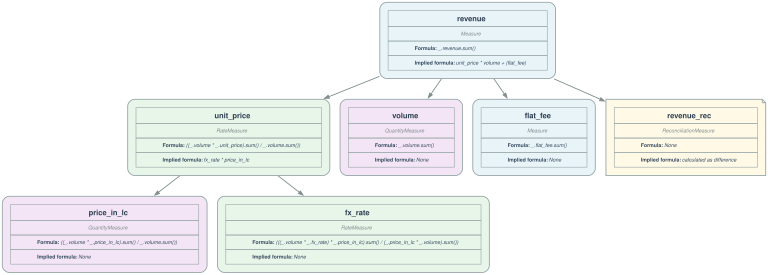

In [6]:
revenue_graph.display(dpi=96, size=(8, 5))

In [7]:
composite_rate = CompositeRateMeasure(
    "unit_profit",
    components=[
        revenue_graph.rate,
        cost_graph.rate,
    ],
)

other_components = revenue_graph.other_components + cost_graph.other_components
components = [composite_rate, revenue_graph.quantity] + other_components

composite_profit_graph = Measure(
    "profit",
    definition=_.revenue.sum() - _.cost.sum(),
    components=components,
)

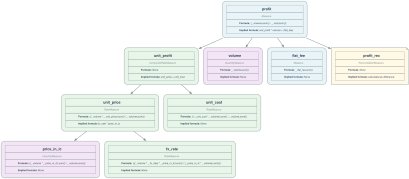

In [8]:
composite_profit_graph.display(dpi=20)

In [ ]:
s = "(((_.volume * _.fx_rate) * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum())"


def recursive_len(x):
    if isinstance(x, list):
        return sum(recursive_len(y) for y in x)
    return len(x)


def parse(s):
    results = []
    g = ""
    i = 0
    while len(s) >= i:
        if s[i] == "(":
            if g:
                results.append(g)
            sub = parse(s[(i + 1) :])
            results.append(sub)
            i += recursive_len(sub)
        elif s[i] == ")":
            return results
        else:
            i += 1
            g += s[i]
    return results


print(parse(s))

# s[1:]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10970ecf0>>
Traceback (most recent call last):
  File "/Users/aurimas/coding/pvm/.venv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


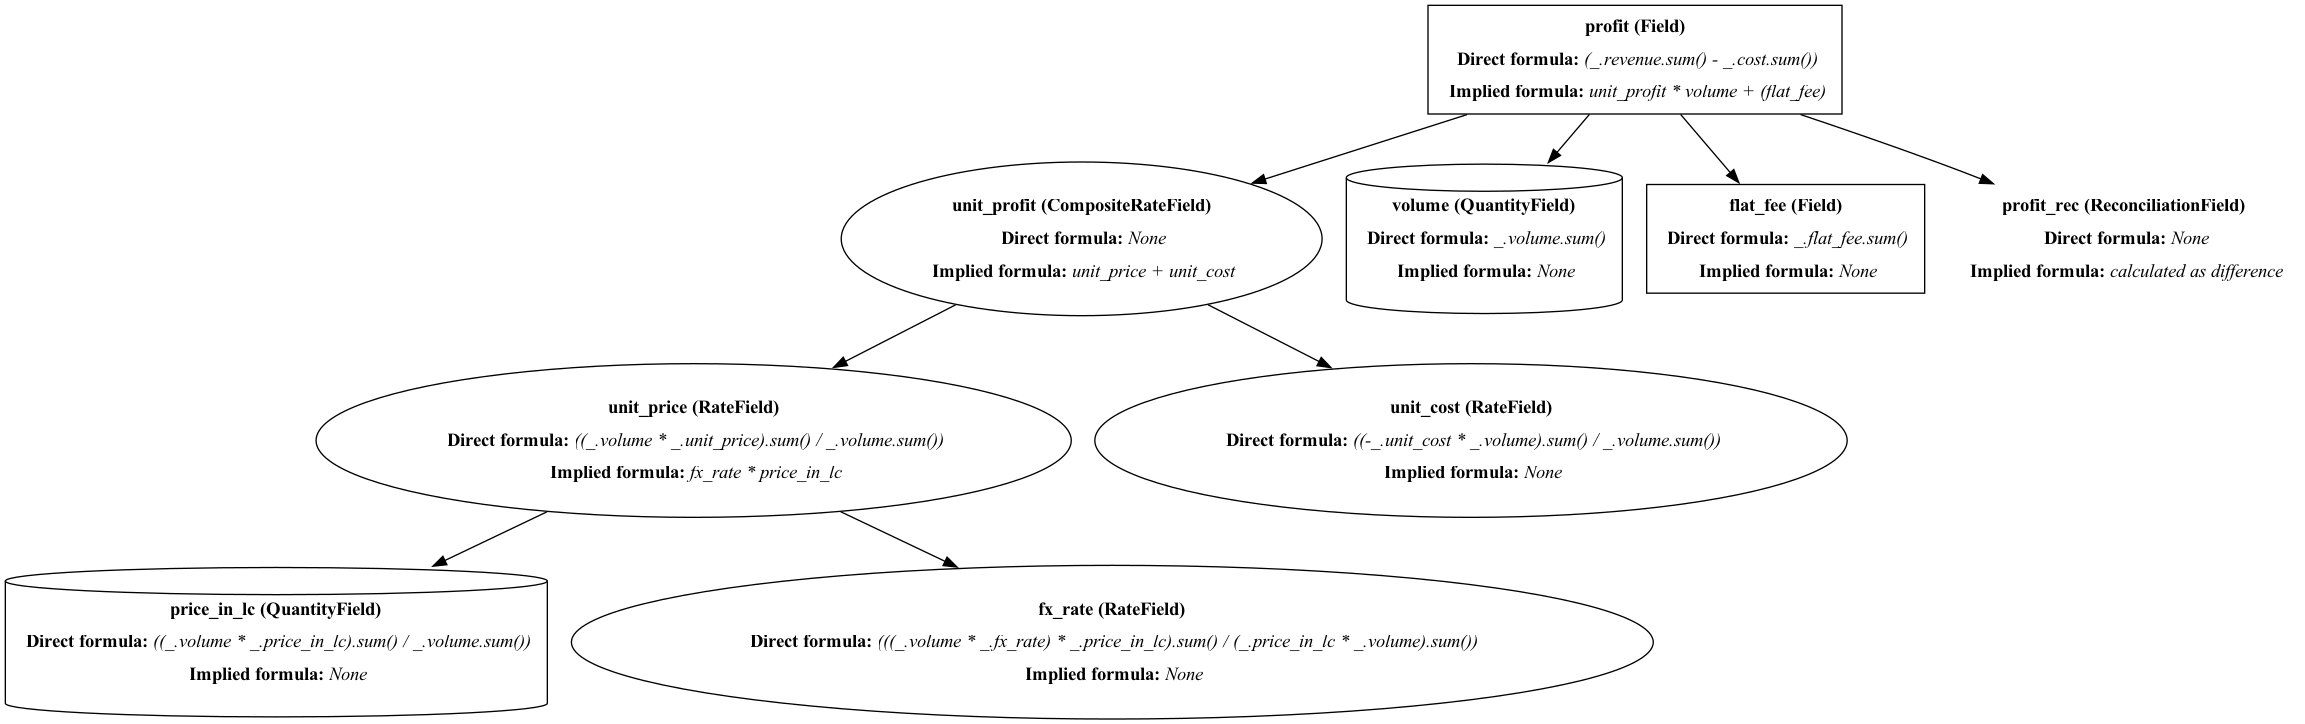

In [7]:
s = composite_profit_graph.to_dot_graph()
from IPython.display import Image

A = pgv.AGraph(string=s)
# A.layout()
A.draw("/tmp/graph.png", prog="dot")
Image(filename="/tmp/graph.png")

In [10]:
import pyperclip

pyperclip.copy(r)

In [8]:
composite_profit_graph.get_flattened_graph()

[Field(name='profit', reconcile=True, components=[CompositeRateField(name='unit_profit', reconcile=False, components=[RateField(name='unit_price', reconcile=False, components=[QuantityField(name='price_in_lc', reconcile=False, components=[], definition=((_.volume * _.price_in_lc).sum() / _.volume.sum()), dot_shape='cylinder'), RateField(name='fx_rate', reconcile=False, components=[], definition=(((_.volume * _.fx_rate) * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum()), dot_shape='ellipse')], definition=((_.volume * _.unit_price).sum() / _.volume.sum()), dot_shape='ellipse'), RateField(name='unit_cost', reconcile=False, components=[], definition=((-_.unit_cost * _.volume).sum() / _.volume.sum()), dot_shape='ellipse')], definition=None, dot_shape='ellipse'), QuantityField(name='volume', reconcile=False, components=[], definition=_.volume.sum(), dot_shape='cylinder'), Field(name='flat_fee', reconcile=True, components=[], definition=_.flat_fee.sum(), dot_shape='rectangle'), Reconc

In [9]:
d = {"1": {"2": None}, "2": {"1": None, "3": None}, "3": {"2": None}}

A = pgv.AGraph(d)

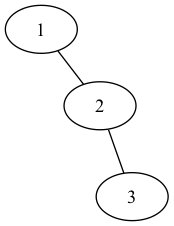

In [10]:
from IPython.display import Image

A.layout()
A.draw()
A.draw("/tmp/graph.png")
Image(filename="/tmp/graph.png")

In [11]:
con = ibis.polars.connect({"sales": datasets.sales.raw})
sales = con.table("sales")

obj = PVM().set_data(sales).set_periods(_.year, ["2020", "2021"]).set_hierarchy([_.country, _.sku])

obj.set_graph(composite_profit_graph)

In [12]:
obj.calculate_effects().to_polars()

country,sku,profit_2020,unit_profit_2020,unit_price_2020,price_in_lc_2020,fx_rate_2020,unit_cost_2020,volume_2020,flat_fee_2020,profit_rec_2020,profit_2021,unit_profit_2021,unit_price_2021,price_in_lc_2021,fx_rate_2021,unit_cost_2021,volume_2021,flat_fee_2021,profit_rec_2021,profit__change__2020,unit_profit__change__2020,unit_price__change__2020,price_in_lc__change__2020,fx_rate__change__2020,unit_cost__change__2020,volume__change__2020,flat_fee__change__2020,profit_rec__change__2020,volume__effect__2020,unit_profit__effect__2020,unit_price__effect__2020,unit_cost__effect__2020,price_in_lc__effect__2020,fx_rate__effect__2020,flat_fee__effect__2020
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Burundi""","""SKU4""",1469.483488,4.449656,11.901103,10.353972,1.1494239,-7.451447,330.246537,0.0,5.2248e-7,1654.753849,4.558426,19.756172,17.341615,1.139235,-15.197746,362.094626,4.172292,-3.9522e-8,185.270362,0.10877,7.855069,6.987643,-0.010189,-7.746299,31.848089,4.172292,-5.6200e-7,141.71304,39.38503,2844.278252,-2804.893221,2908.258682,-63.98041,4.172292
"""Saint Vincent and the Grenadin…","""SKU3""",7073.737105,22.3604,81.237135,90.675167,0.895914,-58.876735,316.351097,0.0,0.000001,10940.421597,20.26347,78.763235,83.382212,0.944605,-58.499765,540.599241,-13.994818,-4.3816e-8,3866.684492,-2.09693,-2.4739,-7.292955,0.048691,0.376969,224.248143,-13.994818,-0.000001,5014.278201,-1133.59889,-1337.388251,203.789361,-3532.19924,2194.810813,-13.994818
"""Ecuador""","""SKU3""",5771.148246,19.08054,77.251149,56.099607,1.377035,-58.170608,304.341554,-35.853068,5.2600e-7,12614.502815,20.570498,76.64765,55.644615,1.37745,-56.077152,612.738207,10.173017,-0.000001,6843.354569,1.489957,-0.603499,-0.454993,0.000414,2.093456,308.396652,46.026086,-0.000002,5884.374774,912.953711,-369.786886,1282.740597,-383.905716,14.118639,46.026086
"""Burundi""","""SKU2""",9900.534715,16.15903,79.940015,69.547897,1.1494239,-63.780984,612.693618,0.0,0.000002,7918.712281,17.81292,80.703874,70.840422,1.139235,-62.890955,443.963078,10.433554,8.6293e-7,-1981.822435,1.65389,0.76386,1.292525,-0.010189,0.89003,-168.73054,10.433554,-8.4125e-7,-2726.521899,734.265912,339.125553,395.140359,659.577949,-320.452299,10.433554
"""Saint Vincent and the Grenadin…","""SKU2""",7776.865514,16.337899,77.268083,86.244995,0.895914,-60.930184,475.51546,7.941905,-0.000002,6673.294767,15.921446,78.252064,82.841064,0.944605,-62.330618,419.138726,0.0,-4.5600e-7,-1103.570747,-0.416453,0.983981,-3.403931,0.048691,-1.400434,-56.376734,-7.941905,0.000002,-921.077393,-174.551451,412.424682,-586.976133,-1278.217652,1690.642204,-7.941905
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Bouvet Island (Bouvetoya)""","""SKU2""",8682.598198,17.601449,81.853191,63.093504,1.297332,-64.251742,493.595726,-5.401608,-1.8554e-7,6341.108834,17.019634,78.029358,64.536648,1.2090705,-61.009724,371.87468,11.937934,-2.0253e-7,-2341.489364,-0.581815,-3.823833,1.443144,-0.088261,3.242019,-121.721047,17.339542,-1.6983e-8,-2142.466747,-216.362159,-1421.986824,1205.624664,696.237437,-2118.22436,17.339542
"""Ecuador""","""SKU4""",980.684719,2.684124,15.033763,10.917484,1.377035,-12.349639,376.515105,-29.928505,-7.6989e-7,1679.572809,3.586422,20.195195,14.661295,1.37745,-16.608772,468.314291,0.0,-5.3291e-8,698.88809,0.902298,5.161432,3.743811,0.000414,-4.259134,91.799187,29.928505,7.1660e-7,246.400399,422.559185,2417.17229,-1994.613105,2414.329072,2.843181,29.928505
"""Saint Vincent and the Grenadin…","""SKU0""",833.037916,1.981721,11.645195,12.99812,0.895914,-9.663474,420.360844,0.0,-1.3733e-7,2353.169028,5.510096,16.094859,17.038722,0.944605,-10.584762,427.064947,0.0,7.4705e-7,1520.131112,3.528375,4.449664,4.040603,0.048691,-0.921288,6.704103,0.0,8.8438e-7,13.285662,1506.845449,1900.295363,-393.449914,1545.988774,354.306569,0.0


In [13]:
assert_frame_equal(
    obj.calculate_effects().to_polars().sort("customer", "sku"),
    datasets.sales.cost_effects_by_customer_sku.sort("customer", "sku"),
    check_column_order=False,
    check_row_order=True,
    check_dtypes=False,
    atol=1e-2,
)

ColumnNotFoundError: "customer" not found

In [14]:
unbound_table = ibis.table(sales.schema())
ibis.to_sql(obj.set_data(unbound_table).calculate_effects())

```sql
SELECT
  "t3"."country",
  "t3"."sku",
  "t3"."profit_2020",
  "t3"."unit_profit_2020",
  "t3"."unit_price_2020",
  "t3"."price_in_lc_2020",
  "t3"."fx_rate_2020",
  "t3"."unit_cost_2020",
  "t3"."volume_2020",
  "t3"."flat_fee_2020",
  "t3"."profit_rec_2020",
  "t3"."profit_2021",
  "t3"."unit_profit_2021",
  "t3"."unit_price_2021",
  "t3"."price_in_lc_2021",
  "t3"."fx_rate_2021",
  "t3"."unit_cost_2021",
  "t3"."volume_2021",
  "t3"."flat_fee_2021",
  "t3"."profit_rec_2021",
  "t3"."profit_2021" - "t3"."profit_2020" AS "profit__change__2020",
  "t3"."unit_profit_2021" - "t3"."unit_profit_2020" AS "unit_profit__change__2020",
  "t3"."unit_price_2021" - "t3"."unit_price_2020" AS "unit_price__change__2020",
  "t3"."price_in_lc_2021" - "t3"."price_in_lc_2020" AS "price_in_lc__change__2020",
  "t3"."fx_rate_2021" - "t3"."fx_rate_2020" AS "fx_rate__change__2020",
  "t3"."unit_cost_2021" - "t3"."unit_cost_2020" AS "unit_cost__change__2020",
  "t3"."volume_2021" - "t3"."volume_2020" AS "volume__change__2020",
  "t3"."flat_fee_2021" - "t3"."flat_fee_2020" AS "flat_fee__change__2020",
  "t3"."profit_rec_2021" - "t3"."profit_rec_2020" AS "profit_rec__change__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."volume_2021" - "t3"."volume_2020"
    ) * "t3"."unit_profit_2020" * 1.0
    ELSE (
      (
        "t3"."volume_2021" * "t3"."unit_profit_2021"
      ) - (
        "t3"."volume_2020" * "t3"."unit_profit_2020"
      )
    ) * 1.0
  END AS "volume__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_profit_2021" - "t3"."unit_profit_2020"
    ) * "t3"."volume_2021" * 1.0
    ELSE 0
  END AS "unit_profit__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_price_2021" - "t3"."unit_price_2020"
    ) * "t3"."volume_2021" * 1.0
    ELSE 0
  END AS "unit_price__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_cost_2021" - "t3"."unit_cost_2020"
    ) * "t3"."volume_2021" * 1.0
    ELSE 0
  END AS "unit_cost__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."price_in_lc_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."price_in_lc_2021", 0) <> 0
    )
    THEN (
      "t3"."price_in_lc_2021" - "t3"."price_in_lc_2020"
    ) * "t3"."fx_rate_2020" * CASE
      WHEN (
        COALESCE("t3"."volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."volume_2021", 0) <> 0
      )
      THEN "t3"."volume_2021" * 1.0
      ELSE 0
    END
    ELSE (
      (
        "t3"."price_in_lc_2021" * "t3"."fx_rate_2021"
      ) - (
        "t3"."price_in_lc_2020" * "t3"."fx_rate_2020"
      )
    ) * CASE
      WHEN (
        COALESCE("t3"."volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."volume_2021", 0) <> 0
      )
      THEN "t3"."volume_2021" * 1.0
      ELSE 0
    END
  END AS "price_in_lc__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."price_in_lc_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."price_in_lc_2021", 0) <> 0
    )
    THEN (
      "t3"."fx_rate_2021" - "t3"."fx_rate_2020"
    ) * "t3"."price_in_lc_2021" * CASE
      WHEN (
        COALESCE("t3"."volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."volume_2021", 0) <> 0
      )
      THEN "t3"."volume_2021" * 1.0
      ELSE 0
    END
    ELSE 0
  END AS "fx_rate__effect__2020",
  (
    "t3"."flat_fee_2021" - "t3"."flat_fee_2020"
  ) * 1.0 AS "flat_fee__effect__2020"
FROM (
  SELECT
    "t2"."country",
    "t2"."sku",
    COALESCE(SUM("t2"."profit") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "profit_2020",
    COALESCE(SUM("t2"."unit_profit") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_profit_2020",
    COALESCE(SUM("t2"."unit_price") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_price_2020",
    COALESCE(SUM("t2"."price_in_lc") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "price_in_lc_2020",
    COALESCE(SUM("t2"."fx_rate") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "fx_rate_2020",
    COALESCE(SUM("t2"."unit_cost") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_cost_2020",
    COALESCE(SUM("t2"."volume") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "volume_2020",
    COALESCE(SUM("t2"."flat_fee") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "flat_fee_2020",
    COALESCE(SUM("t2"."profit_rec") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "profit_rec_2020",
    COALESCE(SUM("t2"."profit") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "profit_2021",
    COALESCE(SUM("t2"."unit_profit") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_profit_2021",
    COALESCE(SUM("t2"."unit_price") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_price_2021",
    COALESCE(SUM("t2"."price_in_lc") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "price_in_lc_2021",
    COALESCE(SUM("t2"."fx_rate") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "fx_rate_2021",
    COALESCE(SUM("t2"."unit_cost") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_cost_2021",
    COALESCE(SUM("t2"."volume") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "volume_2021",
    COALESCE(SUM("t2"."flat_fee") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "flat_fee_2021",
    COALESCE(SUM("t2"."profit_rec") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "profit_rec_2021"
  FROM (
    SELECT
      "t1"."country",
      "t1"."sku",
      CAST("t1"."year" AS TEXT) AS "__period__",
      SUM("t1"."revenue") - SUM("t1"."cost") AS "profit",
      (
        SUM("t1"."volume" * "t1"."unit_price") / SUM("t1"."volume")
      ) + 0 + (
        SUM(-(
          "t1"."unit_cost"
        ) * "t1"."volume") / SUM("t1"."volume")
      ) AS "unit_profit",
      SUM("t1"."volume" * "t1"."unit_price") / SUM("t1"."volume") AS "unit_price",
      SUM("t1"."volume" * "t1"."price_in_lc") / SUM("t1"."volume") AS "price_in_lc",
      SUM("t1"."volume" * "t1"."fx_rate" * "t1"."price_in_lc") / SUM("t1"."price_in_lc" * "t1"."volume") AS "fx_rate",
      SUM(-(
        "t1"."unit_cost"
      ) * "t1"."volume") / SUM("t1"."volume") AS "unit_cost",
      SUM("t1"."volume") AS "volume",
      SUM("t1"."flat_fee") AS "flat_fee",
      (
        SUM("t1"."revenue") - SUM("t1"."cost")
      ) - (
        (
          (
            (
              SUM("t1"."volume" * "t1"."unit_price") / SUM("t1"."volume")
            ) + 0 + (
              SUM(-(
                "t1"."unit_cost"
              ) * "t1"."volume") / SUM("t1"."volume")
            )
          ) * SUM("t1"."volume")
        ) + (
          SUM("t1"."flat_fee") + 0
        )
      ) AS "profit_rec"
    FROM (
      SELECT
        *
      FROM "unbound_table_0" AS "t0"
      WHERE
        CAST("t0"."year" AS TEXT) IN ('2020', '2021')
    ) AS "t1"
    GROUP BY
      1,
      2,
      3
  ) AS "t2"
  GROUP BY
    1,
    2
) AS "t3"
```

In [15]:
obj.calculate_effects().to_polars().select(
    "sku",
    "country",
    "unit_price__effect__2020",
    "price_in_lc__effect__2020",
    "fx_rate__effect__2020",
).with_columns(
    (pl.col("unit_price__effect__2020") - pl.col("price_in_lc__effect__2020") - pl.col("fx_rate__effect__2020")).alias(
        "diff",
    ),
).sort(["country", "sku"])

IbisError: Expression contains unbound tables and therefore cannot be executed. Use `<backend>.execute(expr)` to execute against an explicit backend, or rebuild the expression using bound tables instead.